# EXPL_01 — Global Feature Importance

This notebook reads the **frozen final artifacts** one horizon at a time and
aggregates tree feature importance back to the 22 public model features.

Important: tree feature importance measures usage in fitted trees; it does not
show direction and it is not causal.


In [1]:
# Import libraries
from pathlib import Path
import sys
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "explainability.yaml"
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/explainability.yaml')

In [3]:
# Import modules for generating explainability
from src.ontario_peak_risk.explainability.common import (
    load_explainability_config,
    ensure_phase_directories,
    load_final_metadata,
)

In [4]:
# Load parameters
config, project_root = load_explainability_config(CONFIG_PATH)
phase_paths = ensure_phase_directories(config, project_root)
metadata = load_final_metadata(config, project_root)

print("Project root:", project_root)
print("RF:", metadata["rf"]["algorithm"], "| horizons:", metadata["rf"]["horizons"])
print("XGB:", metadata["xgb"]["algorithm"], "| horizons:", metadata["xgb"]["horizons"])
print("Explainability output:", phase_paths["outputs_dir"])


Project root: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk
RF: RandomForestRegressor | horizons: 24
XGB: XGBoostClassifier | horizons: 24
Explainability output: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\outputs\explainability


In [6]:
from src.ontario_peak_risk.explainability.importance import (
    run_builtin_importance,
    summarize_global_importance,
)
from src.ontario_peak_risk.explainability.plotting import (
    top_importance_plot,
    family_importance_plot,
    importance_heatmap,
)
from src.ontario_peak_risk.explainability.reporting import (
    write_global_importance_report,
)




In [10]:
# load horizonts
horizons = list(config["analysis"]["global_importance_horizons"])


## Random Forest forecasting importance

Only one RF artifact is retained in memory at a time. This can still take time
because all 24 large files must be read once.


In [11]:
rf_importance, rf_transformed = run_builtin_importance(
    "rf", horizons, metadata["rf"], config, project_root
)
print("RF horizon-feature rows:", len(rf_importance))
display(rf_importance.head(20))


RF horizon-feature rows: 528


,task,horizon,feature,feature_family,importance,importance_pct
0,rf,1,target_lag_24h,demand_history,0.682467,68.246739
1,rf,1,target_lag_48h,demand_history,0.173537,17.353711
2,rf,1,target_lag_168h,demand_history,0.072293,7.229309
3,rf,1,origin__Temp (°C),weather,0.029476,2.947642
4,rf,1,origin_rolling_mean_24h,demand_history,0.022634,2.263411
5,rf,1,origin_rolling_std_24h,demand_history,0.004765,0.476533
6,rf,1,origin__reported_premise_count,context,0.002322,0.232178
7,rf,1,fsa,spatial,0.002082,0.208180
8,rf,1,origin_rolling_mean_168h,demand_history,0.001983,0.198258
9,rf,1,target_hour,calendar_time,0.001431,0.143080


## XGBoost Peak-Risk importance

In [12]:
xgb_importance, xgb_transformed = run_builtin_importance(
    "xgb", horizons, metadata["xgb"], config, project_root
)
print("XGB horizon-feature rows:", len(xgb_importance))
display(xgb_importance.head(20))


XGB horizon-feature rows: 528


,task,horizon,feature,feature_family,importance,importance_pct
0,xgb,1,target_season,calendar_time,0.178049,17.804888
1,xgb,1,target_hour,calendar_time,0.169973,16.997271
2,xgb,1,fsa,spatial,0.157688,15.768764
3,xgb,1,target_hour_sin,calendar_time,0.136478,13.647829
4,xgb,1,origin__Temp (°C),weather,0.080075,8.007470
5,xgb,1,target_month_cos,calendar_time,0.058903,5.890285
6,xgb,1,target_lag_24h,demand_history,0.029207,2.920715
7,xgb,1,target_month_sin,calendar_time,0.021502,2.150238
8,xgb,1,target_hour_cos,calendar_time,0.021225,2.122528
9,xgb,1,target_month,calendar_time,0.020689,2.068938


In [13]:
importance = pd.concat(
    [rf_importance, xgb_importance], ignore_index=True
)
global_summary = summarize_global_importance(importance)

family_summary = (
    importance.groupby(
        ["task", "horizon", "feature_family"], observed=True
    )["importance_pct"]
    .sum()
    .reset_index()
)

display(global_summary.head(40))


,task,feature,feature_family,mean_importance_pct,median_importance_pct,min_importance_pct,max_importance_pct
0,rf,target_lag_24h,demand_history,69.681937,69.720247,68.246739,70.527549
1,rf,target_lag_48h,demand_history,17.668316,17.689173,16.825803,18.397747
2,rf,target_lag_168h,demand_history,7.457632,7.435845,7.151724,7.808239
3,rf,origin_rolling_mean_24h,demand_history,1.567094,1.437801,1.176699,2.263411
4,rf,origin__Temp (°C),weather,0.917428,0.621584,0.311911,2.947642
5,rf,origin_rolling_std_24h,demand_history,0.496645,0.472886,0.372636,0.675992
6,rf,origin_rolling_mean_168h,demand_history,0.350717,0.388788,0.198258,0.456273
7,rf,origin__reported_premise_count,context,0.315557,0.328154,0.232178,0.350730
8,rf,origin__Stn Press (kPa),weather,0.289910,0.311669,0.078181,0.416156
9,rf,origin__Rel Hum (%),weather,0.166859,0.183306,0.084115,0.195298


## Global and horizon-comparison figures

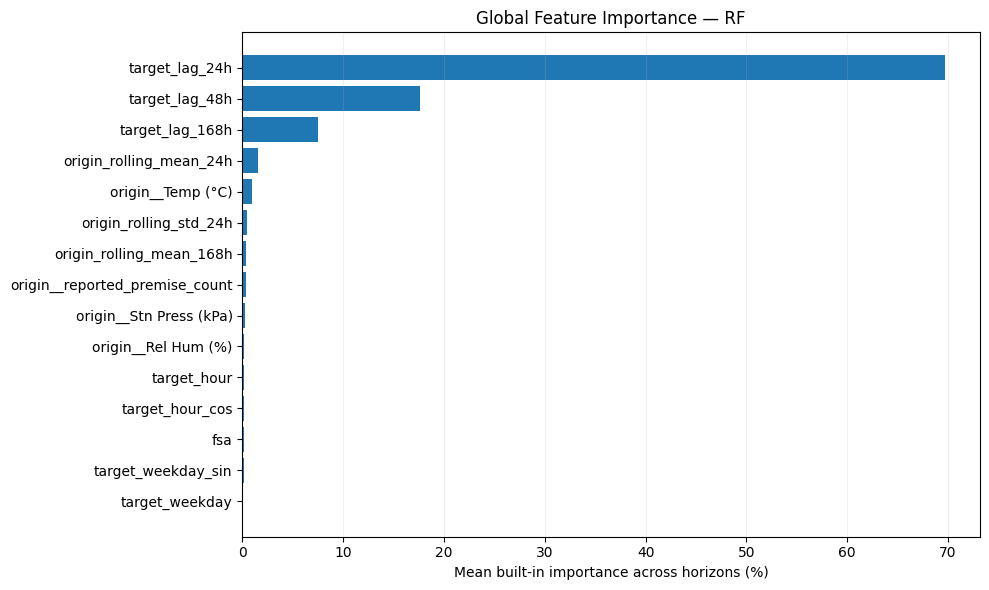

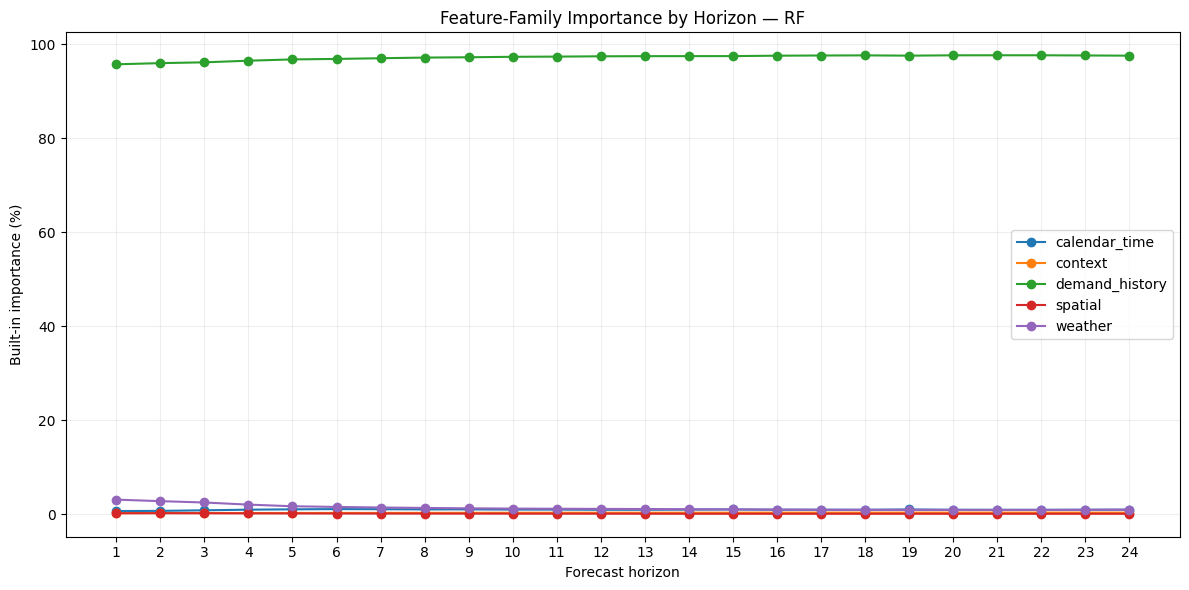

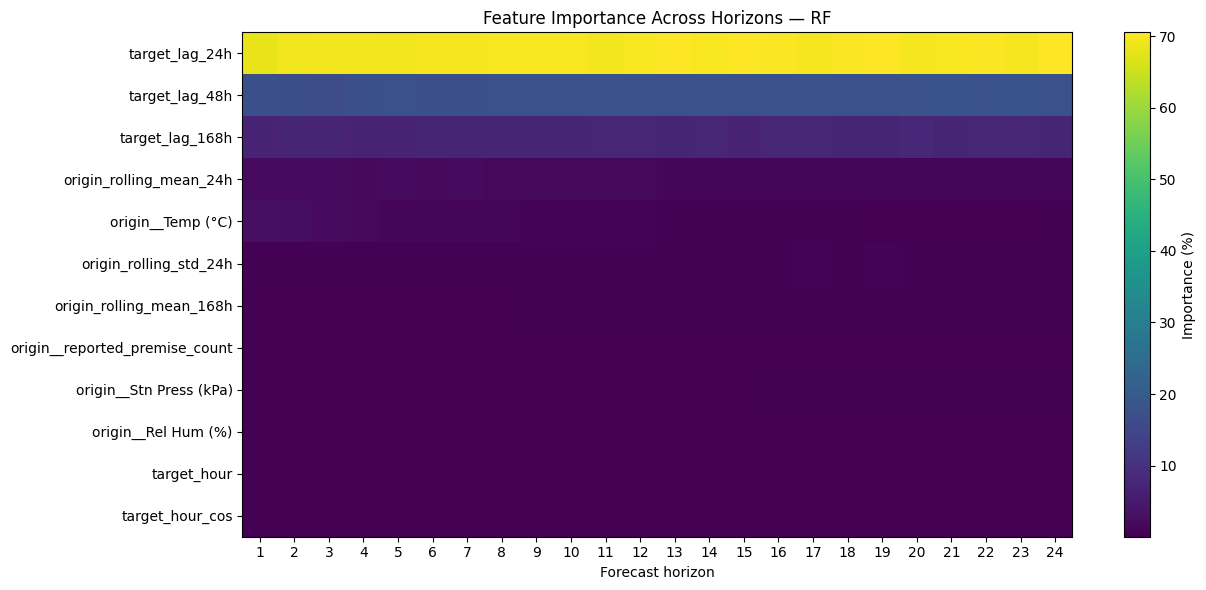

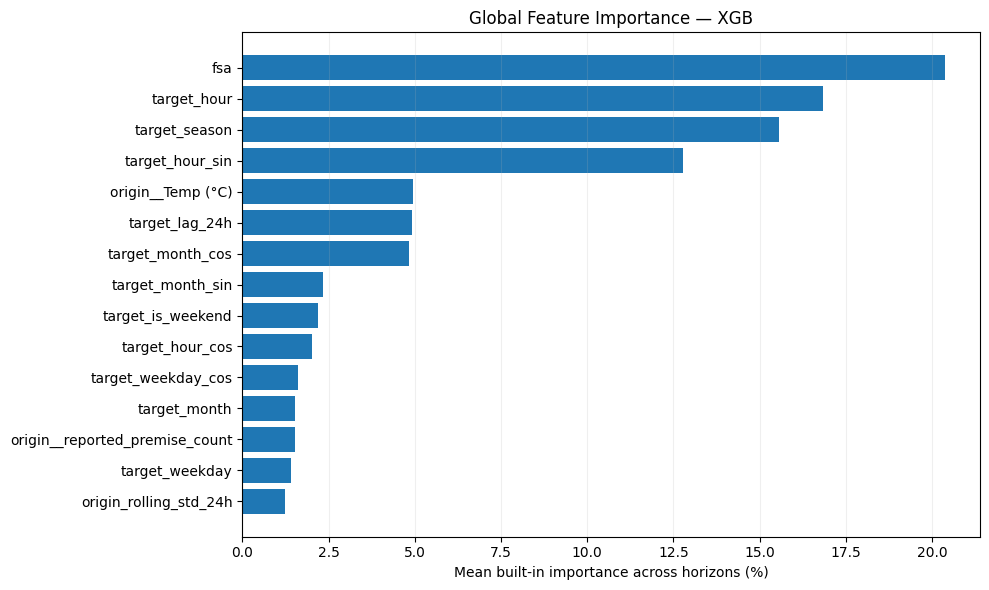

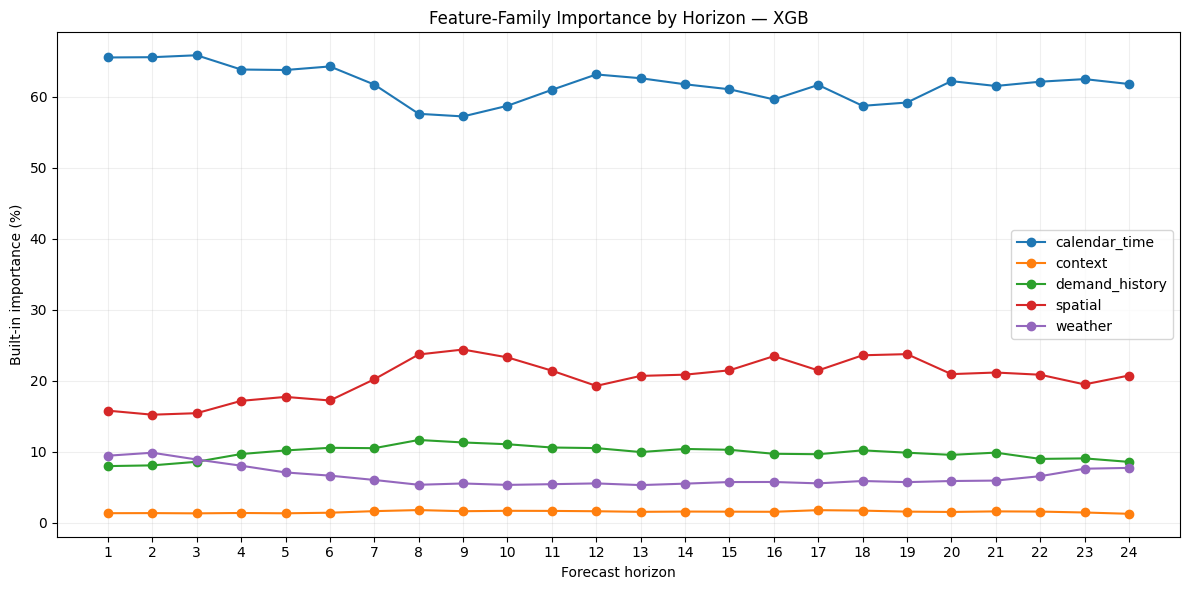

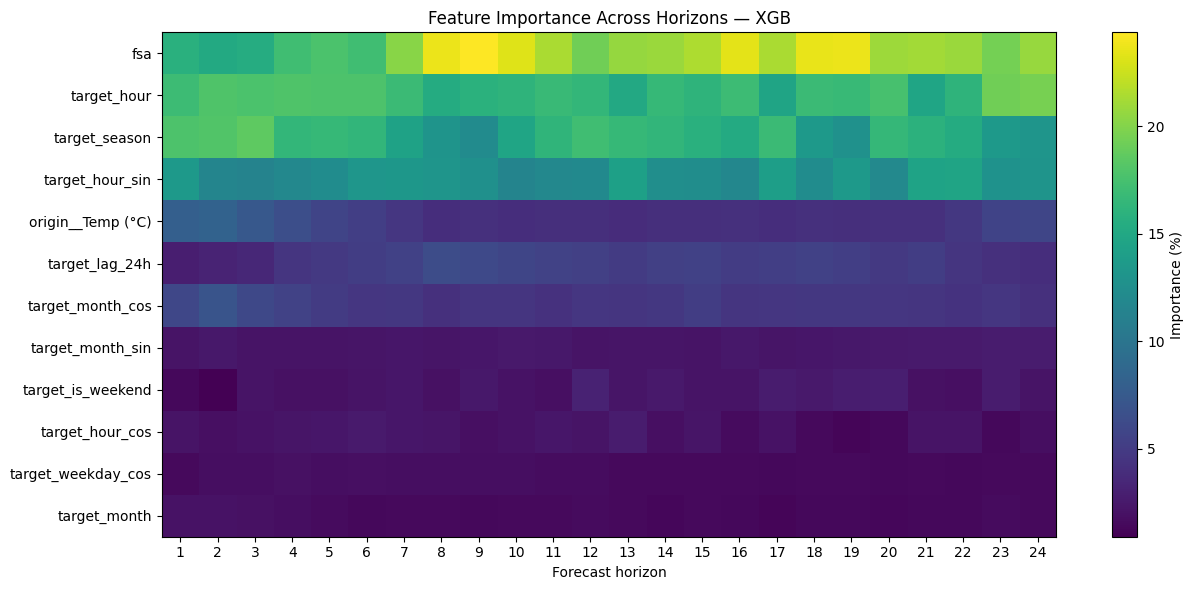

In [14]:
for task in ["rf", "xgb"]:
    top_importance_plot(
        global_summary, task,
        top_n=config["analysis"]["top_n_features"],
    )
    plt.show()

    family_importance_plot(importance, task)
    plt.show()

    importance_heatmap(
        importance, task,
        top_n=min(12, config["analysis"]["top_n_features"]),
    )
    plt.show()


In [15]:
importance.to_csv(
    phase_paths["outputs_dir"] / "EXPL_01_importance_by_horizon.csv",
    index=False,
)
global_summary.to_csv(
    phase_paths["outputs_dir"] / "EXPL_01_global_importance_summary.csv",
    index=False,
)
family_summary.to_csv(
    phase_paths["outputs_dir"] / "EXPL_01_family_importance_by_horizon.csv",
    index=False,
)

write_global_importance_report(
    phase_paths["docs_dir"] / "EXPL_01_Global_Feature_Importance.md",
    global_summary,
    (
        family_summary.groupby(["task", "feature_family"], observed=True)
        ["importance_pct"].mean().reset_index()
        .sort_values(["task", "importance_pct"], ascending=[True, False])
    ),
)

print("EXPL_01 RESULT: COMPLETE")


EXPL_01 RESULT: COMPLETE
